In [19]:
import os
import numpy as np
from itertools import product

os.environ['PYGAME_HIDE_SUPPORT_PROMPT'] = '1'

import farptest
from farptest import test_mp

In [20]:
farptest.config = farptest.RectangularWorldConfig.from_yaml(farptest.cwd / "ttd.yaml")

results = test_mp(100)

  0%|          | 0/100 [00:00<?, ?it/s]

n:  1 Counter({'Time to Detect sub': 1548, 'How many red on goal': 86})


  0%|          | 0/100 [00:00<?, ?it/s]

n:  2 Counter({'Time to Detect sub': 2871, 'Time to Capture sub': 185, 'How many red on goal': 76})


  0%|          | 0/100 [00:00<?, ?it/s]

...

n:  7 Counter({'Time to Detect sub': 5019, 'Time to Capture sub': 198, 'How many red on goal': 51})


  0%|          | 0/100 [00:00<?, ?it/s]

n:  8 Counter({'Time to Detect sub': 5392, 'Time to Capture sub': 198, 'How many red on goal': 47})


  0%|          | 0/100 [00:00<?, ?it/s]

n:  9 Counter({'Time to Detect sub': 5681, 'Time to Capture sub': 204, 'How many red on goal': 45})
[{'n': 1, 'Time to Detect': -222, 'Time to Detect sub': 222, 'Time to Capture sub': -1, 'How many red on goal': 0}, {'n': 1, 'Time to Detect': -1000, 'Time to Detect sub': -1, 'Time to Capture sub': -1, 'How many red on goal': 1}, {'n': 1, 'Time to Detect': -1000, 'Time to Detect sub': -1, 'Time to Capture sub': -1, 'How many red on goal': 1}, {'n': 1, 'Time to Detect': -1000, 'Time to Detect sub': -1, 'Time to Capture sub': -1, 'How many red on goal': 1}, {'n': 1, 'Time to Detect': -1000, 'Time to Detect sub': -1, 'Time to Capture sub': -1, 'How many red on goal': 1}, {'n': 1, 'Time to Detect': -7, 'Time to Detect sub': 7, 'Time to Capture sub': -1, 'How many red on goal': 0}, {'n': 1, 'Time to Detect': -1000, 'Time to Detect sub': -1, 'Time to Capture sub': -1, 'How many red on goal': 1}, {'n': 1, 'Time to Detect': -115, 'Time to Detect sub': 115, 'Time to Capture sub': -1, 'How many r

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


df = pd.DataFrame(results)

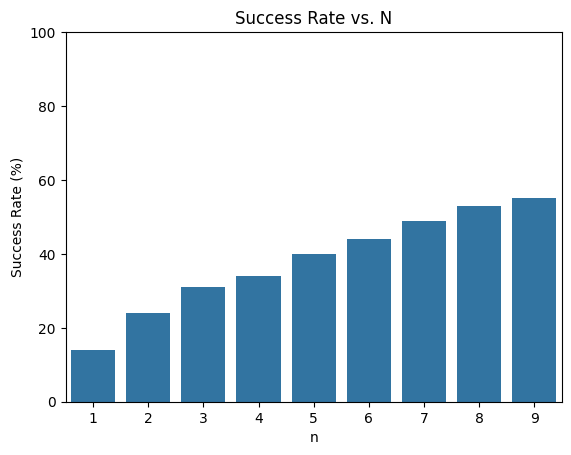

In [22]:
sns.countplot(data=df[df['How many red on goal'] == 0], x='n', hue='How many red on goal', palette='tab10',)
plt.ylabel("Success Rate (%)")
plt.title("Success Rate vs. N")
plt.ylim(0, 100)
plt.gca().get_legend().remove()

Text(0.5, 1.0, 'Distribution of Time to Detect (sim timesteps) vs. n. Lower is better.')

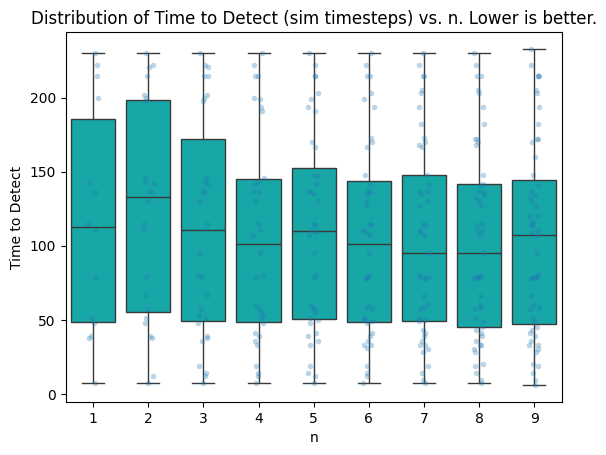

In [23]:
# sns.swarmplot(data=df, x='n', y='Time to capture', size=4)

# name = 'Time to Capture'
name = 'Time to Detect'

dfm = df[0 < df[f'{name} sub']].abs()
sns.stripplot(data=dfm, x='n', y=name, size=4, alpha=0.3)
sns.boxplot(
    dfm, x="n", y=name,
    color="c",
    # fliersize=1, whis=(5, 95)
    # palette="vlag",
    # whis=[0, 100], width=.6, palette="vlag"
)
plt.title(f"Distribution of {name} (sim timesteps) vs. n. Lower is better.")


In [64]:
with open('../../ttc_grid.csv', 'r') as f:
    cdf = pd.read_csv(f)

with open('../../ttd_grid.csv', 'r') as f:
    ddf = pd.read_csv(f)

df1 = cdf

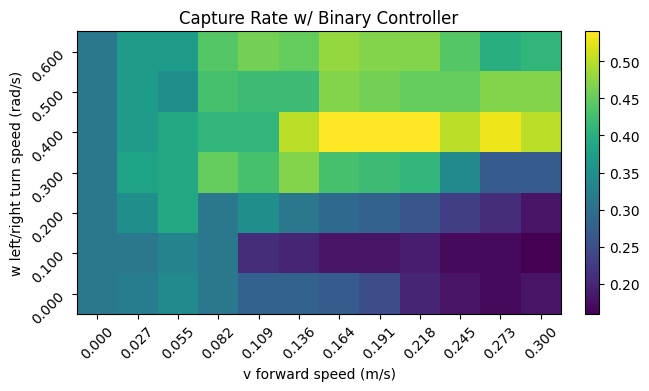

In [65]:
x, y = np.meshgrid(df1['v'].unique(), df1['w'].unique())
x.flatten(), y.flatten()

counts = pd.DataFrame(df1.groupby(['v', 'w'])['How many red on goal'].sum())
plt.subplots(1, 1, layout='compressed')
plt.imshow((100 - counts.unstack().T[::-1]) / 100)
plt.xticks(
    np.arange(df1['v'].unique().size),
    [f'{v:.3f}' for v in df1['v'].unique()],
    rotation=45,
)
plt.yticks(
    np.arange(df1['w'].unique().size)[::-1],
    [f'{w:.3f}' for w in df1['w'].unique()],
    rotation=45,
)
plt.colorbar()
plt.xlabel('v forward speed (m/s)')
plt.ylabel('w left/right turn speed (rad/s)')
success = 'Capture' if df1 is cdf else 'Detection'
plt.title(f'{success} Rate w/ Binary Controller')
# plt.tight_layout()
plt.savefig(f'{success}_rate_grid.pdf')

In [ ]:
# df1[df1['Time to detect sub'] > 0].groupby(['v', 'w']).mean()['Time to detect sub'].unstack().T[::-1]

v,0.000000,0.027273,0.054545,0.081818,0.109091,0.136364,0.163636,0.190909,0.218182,0.245455,0.272727,0.300000
w,,,,,,,,,,,,
0.6,163.743590,165.025641,161.759494,157.645570,158.317073,153.950617,152.631579,160.162500,156.337662,150.858974,147.434211,146.987342
0.5,163.641026,166.074074,160.545455,161.101266,162.200000,156.175676,156.932432,150.868421,147.554054,147.702703,145.866667,140.447368
0.4,162.139241,164.400000,161.103896,152.065789,147.424658,149.828947,153.280000,151.337838,145.309859,140.716216,134.184211,134.040541
0.3,160.417722,158.558442,154.233766,153.272727,146.987013,149.480000,142.891892,138.915493,131.956522,127.385714,119.835821,119.846154
0.2,161.923077,155.069444,156.310811,144.735294,132.875000,128.400000,108.056604,103.229167,98.869565,89.564103,81.162162,79.000000
0.1,165.126582,146.500000,123.265306,107.292683,100.513514,93.351351,85.171429,80.818182,72.774194,70.593750,67.343750,64.343750
0.0,146.464286,131.346939,120.553191,109.522727,98.560976,86.846154,80.631579,77.648649,73.702703,71.828571,68.342857,65.060606


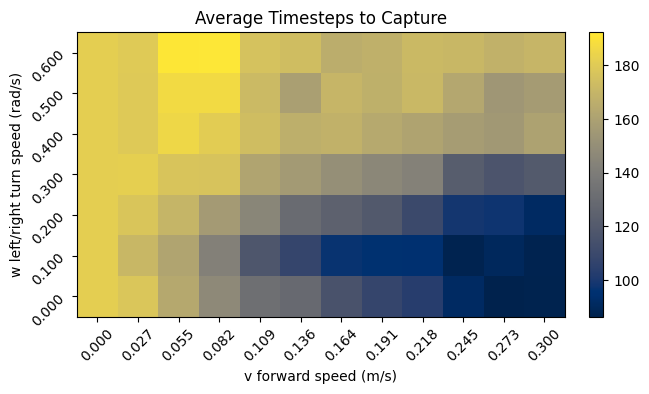

In [66]:
action = 'capture' if df1 is cdf else 'detect'
filtered = df1[df1[f'Time to {action} sub'] > 0].groupby(['v', 'w']).mean()
times = pd.DataFrame(filtered.groupby(['v', 'w']).mean())[f'Time to {action} sub']

plt.subplots(1, 1, layout='compressed')
plt.imshow((times.unstack().T[::-1]), cmap='cividis')
plt.xticks(
    np.arange(df1['v'].unique().size),
    [f'{v:.3f}' for v in df1['v'].unique()],
    rotation=45,
)
plt.yticks(
    np.arange(df1['w'].unique().size)[::-1],
    [f'{w:.3f}' for w in df1['w'].unique()],
    rotation=45,
)
plt.colorbar()
plt.xlabel('v forward speed (m/s)')
plt.ylabel('w left/right turn speed (rad/s)')
success = 'Capture' if df1 is cdf else 'Detection'
plt.title(f'Average Timesteps to {success}')
# plt.tight_layout()
plt.savefig(f'{success}_rate_grid.pdf')

In [ ]:
counts

How many red on goal
v   w                        
0.0 0.0                    42
    0.1                    24
    0.2                    23
    0.3                    23
    0.4                    24
...                       ...
0.3 0.2                    63
    0.3                    36
    0.4                    27
    0.5                    25
    0.6                    23

[84 rows x 1 columns]